<a href="https://colab.research.google.com/github/YBrentt/fundamental-da/blob/main/tuas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use('default')

load Dataset

In [241]:
url = 'https://raw.githubusercontent.com/YBrentt/fundamental-da/main/youtube_recommendation.csv'
df = pd.read_csv(url)

print("Shape awal:", df.shape)
display(df.head())

Shape awal: (536, 10)


,Title,channel_title,published_at,category_id,view_count,like_count,comment_count,likes_to_views_ratio,comments_to_views_ratio,duration_seconds
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,AlofokeMusicSounds,2025-11-16 15:34:55+00:00,10,1405647,140463,9063,0.099928,0.006448,111
1,Moana | Official Teaser,Disney,2025-11-17 17:00:47+00:00,24,2776847,26801,6684,0.009652,0.002407,60
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,CaylusBlox,2025-11-17 22:57:14+00:00,20,1189857,16174,1827,0.013593,0.001535,1082
3,ALLDAY PROJECT - ‘ONE MORE TIME’ M/V,THEBLACKLABEL,2025-11-17 09:00:07+00:00,10,5319161,245621,12869,0.011733,0.002419,203
4,La Lupa | Vendetta Hero Trailer | Overwatch 2,PlayOverwatch,2025-11-17 17:00:06+00:00,20,597542,41742,4728,0.069856,0.007912,215


In [242]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    536 non-null    object 
 1   channel_title            536 non-null    object 
 2   published_at             536 non-null    object 
 3   category_id              536 non-null    int64  
 4   view_count               536 non-null    int64  
 5   like_count               536 non-null    int64  
 6   comment_count            536 non-null    int64  
 7   likes_to_views_ratio     536 non-null    float64
 8   comments_to_views_ratio  536 non-null    float64
 9   duration_seconds         536 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 42.0+ KB


,category_id,view_count,like_count,comment_count,likes_to_views_ratio,comments_to_views_ratio,duration_seconds
count,536.000000,5.360000e+02,5.360000e+02,536.000000,536.000000,536.000000,536.000000
mean,22.453358,2.149755e+07,4.349173e+05,7140.973881,0.027860,0.001054,4811.707090
std,5.859864,4.017878e+07,8.390511e+05,36107.118343,0.019654,0.002187,13759.522713
min,1.000000,2.790700e+04,0.000000e+00,0.000000,0.000000,0.000000,6.000000
25%,20.000000,2.751866e+06,5.593525e+04,1021.750000,0.015335,0.000120,52.000000
50%,24.000000,6.395106e+06,1.565700e+05,2354.500000,0.023618,0.000403,392.500000
75%,27.000000,2.271763e+07,4.635650e+05,5927.750000,0.036448,0.000959,1646.250000
max,28.000000,3.697310e+08,1.087934e+07,810641.000000,0.199095,0.026031,105227.000000


In [243]:
df.isnull().sum()

,0
Title,0
channel_title,0
published_at,0
category_id,0
view_count,0
like_count,0
comment_count,0
likes_to_views_ratio,0
comments_to_views_ratio,0
duration_seconds,0


In [244]:
df = df[['view_count', 'like_count', 'comment_count', 'category_id', 'duration_seconds']].dropna()

In [245]:
df['performance_score'] = df['like_count'] + df['comment_count']

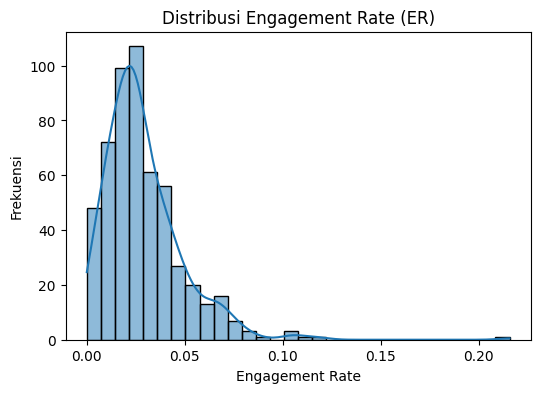

In [246]:
df['er'] = df['performance_score'] / df['view_count']

plt.figure(figsize=(6,4))
sns.histplot(df['er'], bins=30, kde=True)
plt.title('Distribusi Engagement Rate (ER)')
plt.xlabel('Engagement Rate')
plt.ylabel('Frekuensi')
plt.show()

In [247]:
X = df[['view_count', 'category_id', 'duration_seconds']]
y = df['performance_score']

In [248]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))

Jumlah data train: 428
Jumlah data test : 108


In [249]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [250]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n=== HASIL MODEL ===")
print("Intercept      :", model.intercept_)
print("Koefisien ER   :", model.coef_[0])
print("R-Squared (R2) :", r2)
print("RMSE           :", rmse)


=== HASIL MODEL ===
Intercept      : -35821.90432809567
Koefisien ER   : 0.01886437705332113
R-Squared (R2) : 0.3173829270316225
RMSE           : 458881.5980378474
